In [ ]:
# 📓 Range-Doppler Modeli - M3 Macbook Uyumlu (CPU ile Çalışır, MPS Hatası Yok)

# ✅ Hücre 1: Gerekli importlar ve cihaz ayarı (Sadece CPU kullanılır)
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from fpdf import FPDF
from datetime import datetime

# Apple M1/M2 uyumu için GPU yerine CPU kullanılacak

#device = "cpu"
#print(f"✅ Kullanilan cihaz: {device.upper()} (MPS uyumsuzluk önlendi)")


if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("mps kullanıldı")
else:
    device = torch.device("cpu")
    print("cpu kullanıldı")


mps kullanıldı


In [11]:
# ✅ Hücre 2: Veri seti sınıfı
class RangeDopplerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = []
        self.labels = []
        for label in ['target', 'no_target']:
            class_dir = os.path.join(root_dir, label)
            for file in os.listdir(class_dir):
                if file.endswith('.png') or file.endswith('.jpg'):
                    self.image_files.append(os.path.join(class_dir, file))
                    self.labels.append(1 if label == 'target' else 0)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)


In [12]:
# ✅ Hücre 3: Hafifletilmiş Custom CNN modeli (AdaptiveAvgPool kaldırıldı, M2 uyumlu)
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=8)  # sabit havuzlama
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 24, 256),  # 36864 giriş!
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
# ✅ Hücre 4: Dönüşüm ve veri yükleme
# ✅ Eğitim dönüşümleri
train_transform = transforms.Compose([
    transforms.Resize((562, 2318)),  # Sabit boyut (yükseklik, genişlik)
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.RandomAffine(10, translate=(0.1,0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ✅ Test dönüşümleri
test_transform = transforms.Compose([
    transforms.Resize((562, 2318)),  # Sabit boyut
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ✅ Dataset tanımları
train_dataset = RangeDopplerDataset("data/train", transform=train_transform)
test_dataset = RangeDopplerDataset("data/test", transform=test_transform)

# ✅ DataLoader tanımları
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

In [14]:
# ✅ Hücre 5: Modeli eğit, en iyi modeli kaydet (models klasörünü oluşturur)
os.makedirs("models", exist_ok=True)
model = CustomCNN().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
criterion = nn.BCELoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

def train_model(model, train_loader, test_loader, optimizer, criterion, scheduler=None, device='cpu', epochs=10, save_path="models/best_model.pth"):
    model.train()
    best_accuracy = 0.0
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if scheduler:
            scheduler.step()
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")
        accuracy = evaluate_model(model, test_loader, device)
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            torch.save(model.state_dict(), save_path)
            print(f"✅ Yeni en iyi model kaydedildi: {best_accuracy:.4f}")

def evaluate_model(model, test_loader, device='cpu'):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze()
            preds = (outputs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = sum([1 for i in range(len(all_preds)) if all_preds[i]==all_labels[i]]) / len(all_preds)
    print(f"Accuracy: {acc:.4f}")
    return acc

train_model(model, train_loader, test_loader, optimizer, criterion, scheduler, device=device, epochs=10)


Epoch 1, Loss: 0.2766
Accuracy: 0.8550
✅ Yeni en iyi model kaydedildi: 0.8550
Epoch 2, Loss: 0.0949
Accuracy: 0.9850
✅ Yeni en iyi model kaydedildi: 0.9850
Epoch 3, Loss: 0.1326
Accuracy: 0.9850
Epoch 4, Loss: 0.0523
Accuracy: 0.9900
✅ Yeni en iyi model kaydedildi: 0.9900
Epoch 5, Loss: 0.0566
Accuracy: 0.9900
Epoch 6, Loss: 0.0216
Accuracy: 0.9900
Epoch 7, Loss: 0.0186
Accuracy: 0.9900
Epoch 8, Loss: 0.0207
Accuracy: 0.9900
Epoch 9, Loss: 0.0174
Accuracy: 0.9900
Epoch 10, Loss: 0.0185
Accuracy: 0.9900


In [40]:
# ✅ Hücre 6: Tahmin fonksiyonu
from IPython.display import display, Image as IPyImage
from PIL import Image
import torch
from torchvision import transforms

def predict(image_path, model_path="models/best_model.pth", device='cpu'):
    model = CustomCNN()
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor).squeeze()
        result = "Hedef Var ✅" if output > 0.5 else "Hedef Yok ❌"

    # Görseli ve sonucu göster
    display(IPyImage(filename=image_path))
    print(f"{image_path}")
    return result

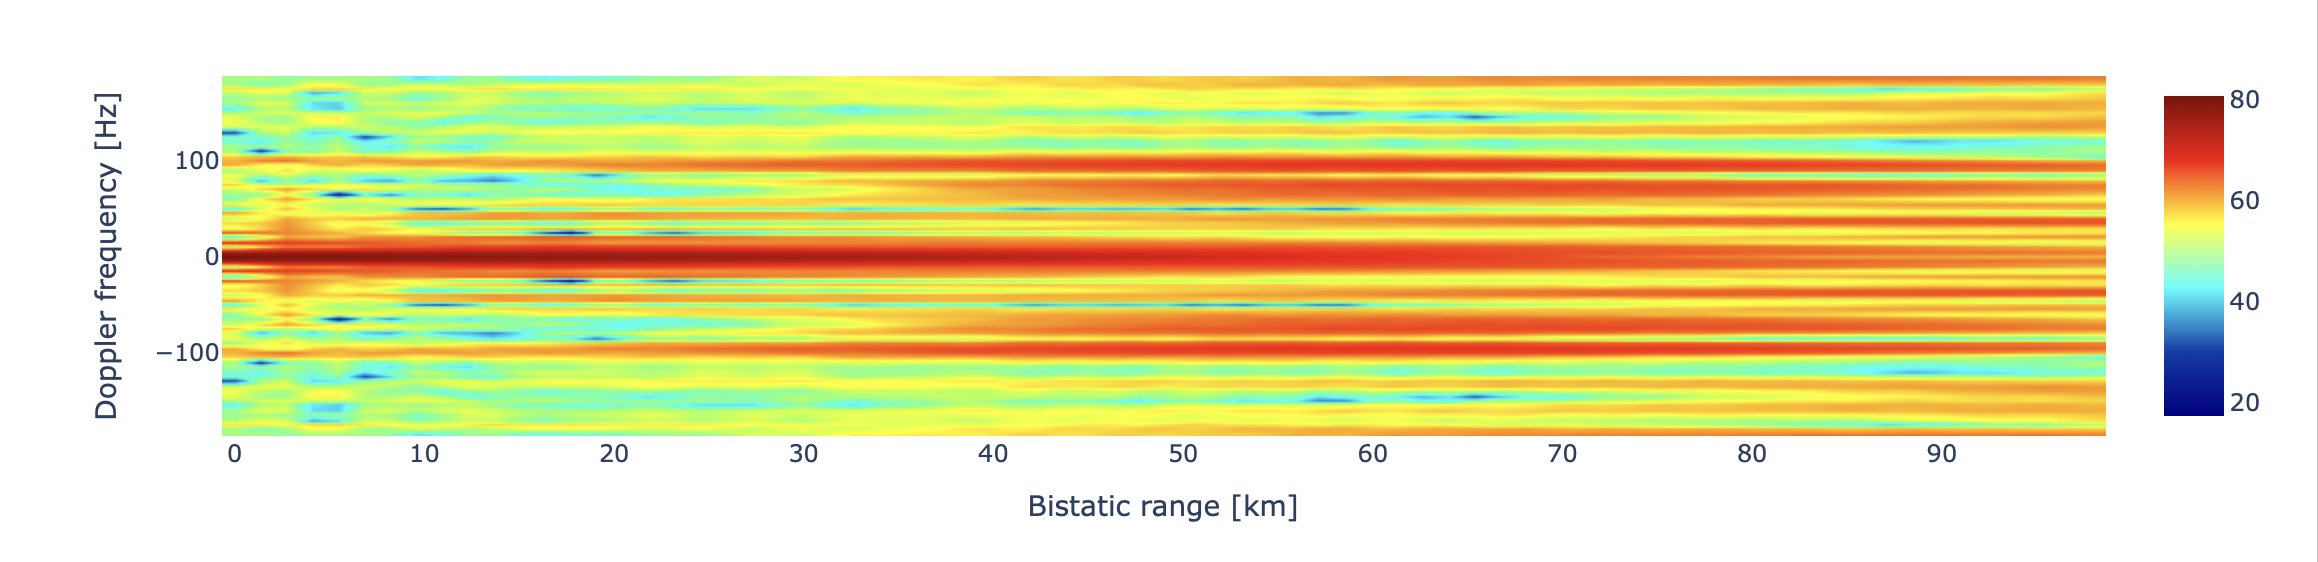

data/test/target/Zaz - Je veux (Studio version, HD) (128kbit_AAC)Part001.png 
Hedef Var ✅


In [42]:
# ✅ Hücre 7: Tahmin Örneği
image_path = "data/test/target/Zaz - Je veux (Studio version, HD) (128kbit_AAC)Part001.png"  # Örneği değiştir
print(predict(image_path, device=device))


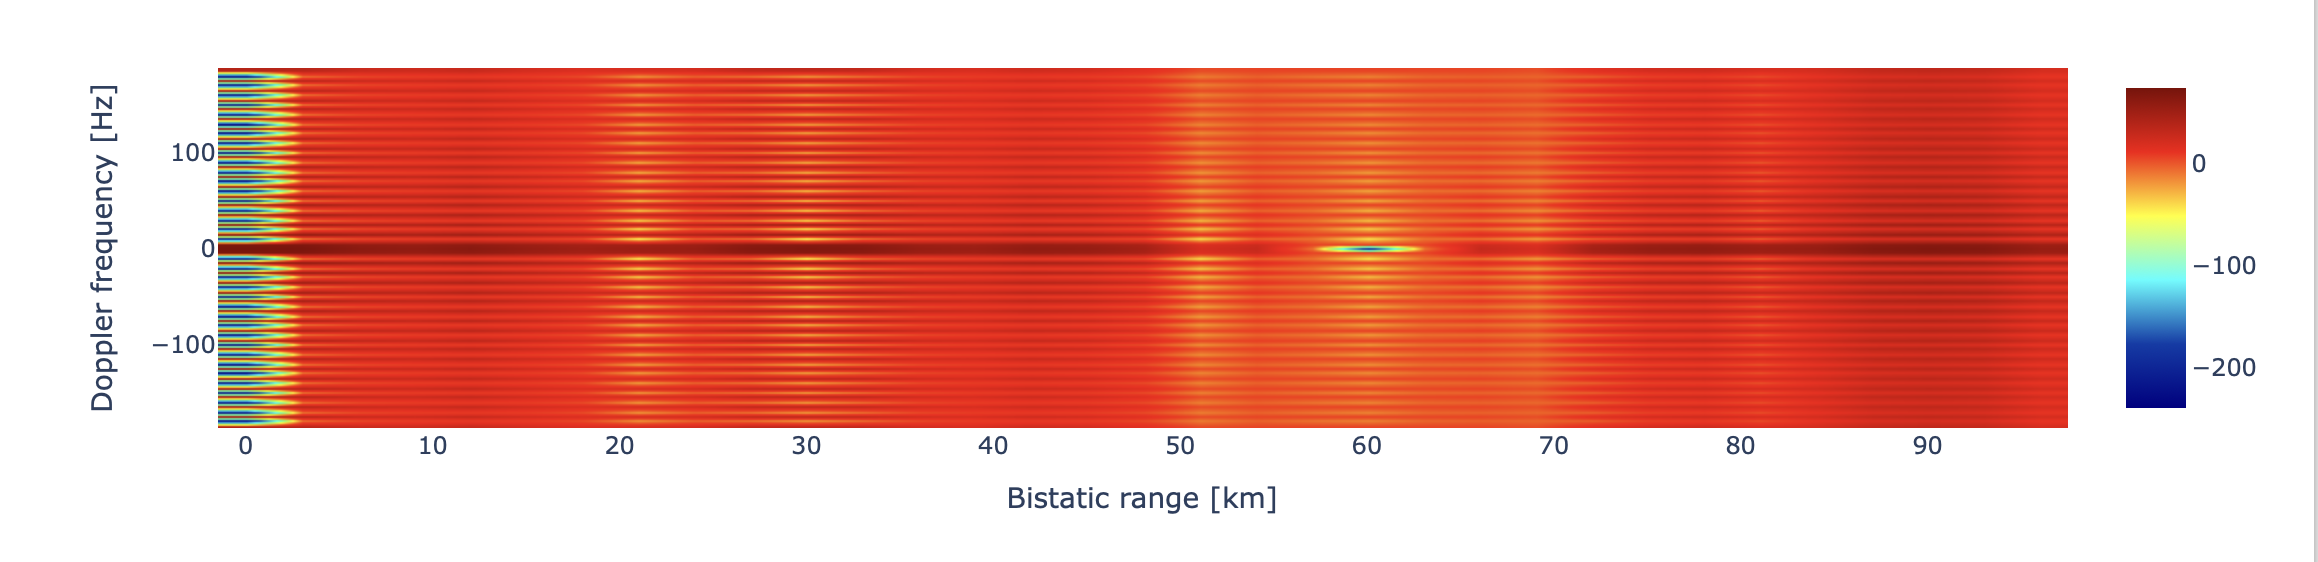

data/test/target/threshold2.png 
data/test/target/threshold2.png için tahmin sonucu: Hedef Yok ❌


In [43]:
# ✅ Hücre 8: Tahmin Örneği 2 ----- BU ÖRNEKTE HEDEFİN VAR OLUP OLMADIĞINI BİLMİYORUZ
image_path = "data/test/target/threshold2.png"  # Örneği değiştir  
print(f"{image_path} için tahmin sonucu: {predict(image_path, device=device)}")

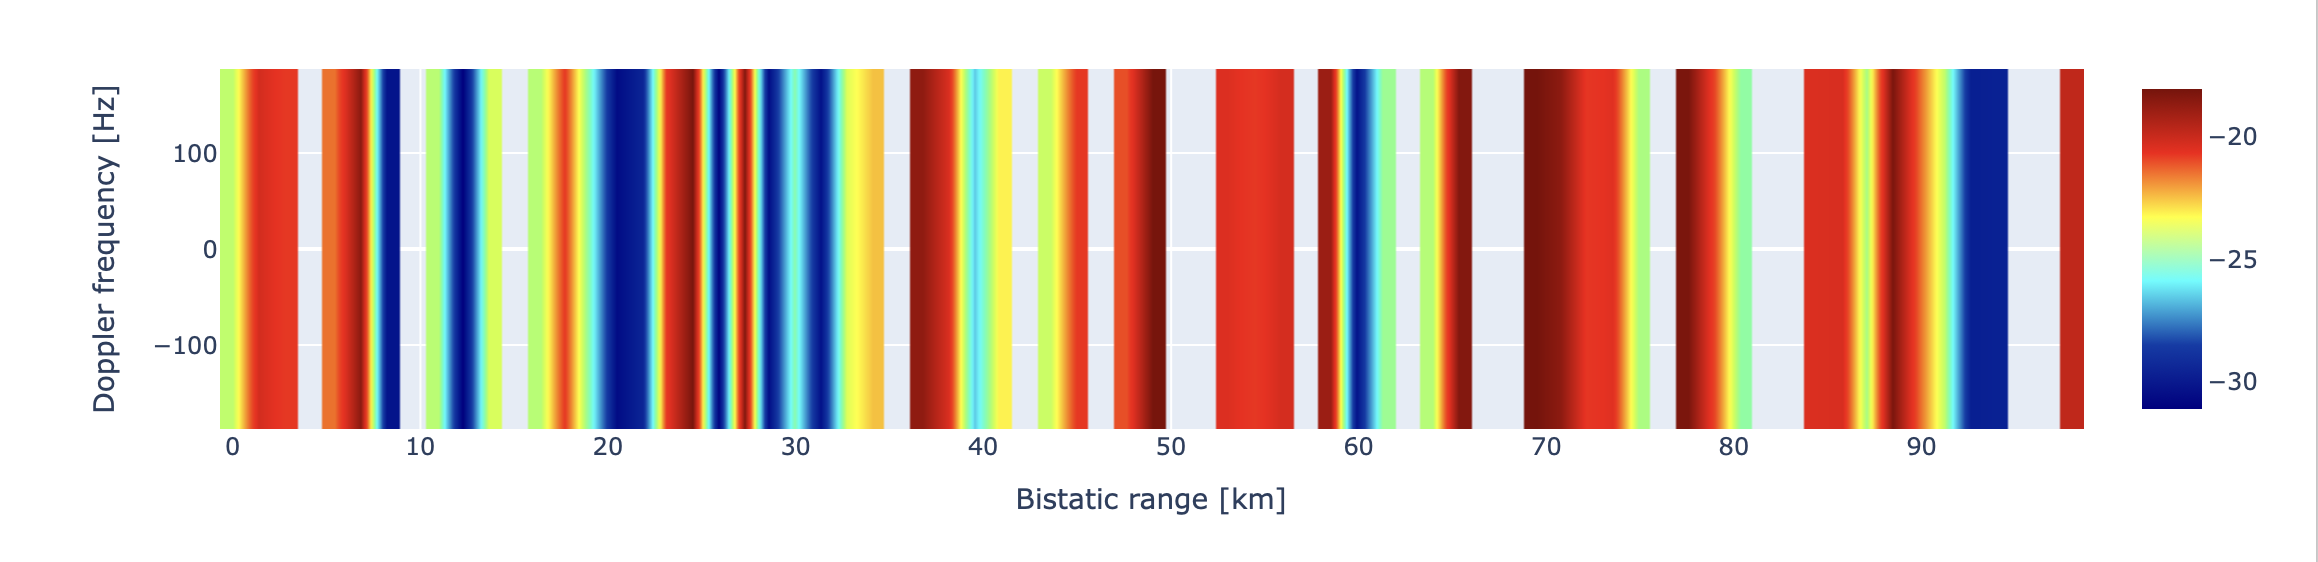

data/test/no_target/4-Enrique Iglesias - Bailamos (128kbit_AAC)Part003.png 
data/test/no_target/4-Enrique Iglesias - Bailamos (128kbit_AAC)Part003.png için tahmin sonucu: Hedef Yok ❌


In [44]:
# ✅ Hücre 9: Tahmin Örneği 3
image_path = "data/test/no_target/4-Enrique Iglesias - Bailamos (128kbit_AAC)Part003.png"  # Örneği değiştir
print(f"{image_path} için tahmin sonucu: {predict(image_path, device=device)}")

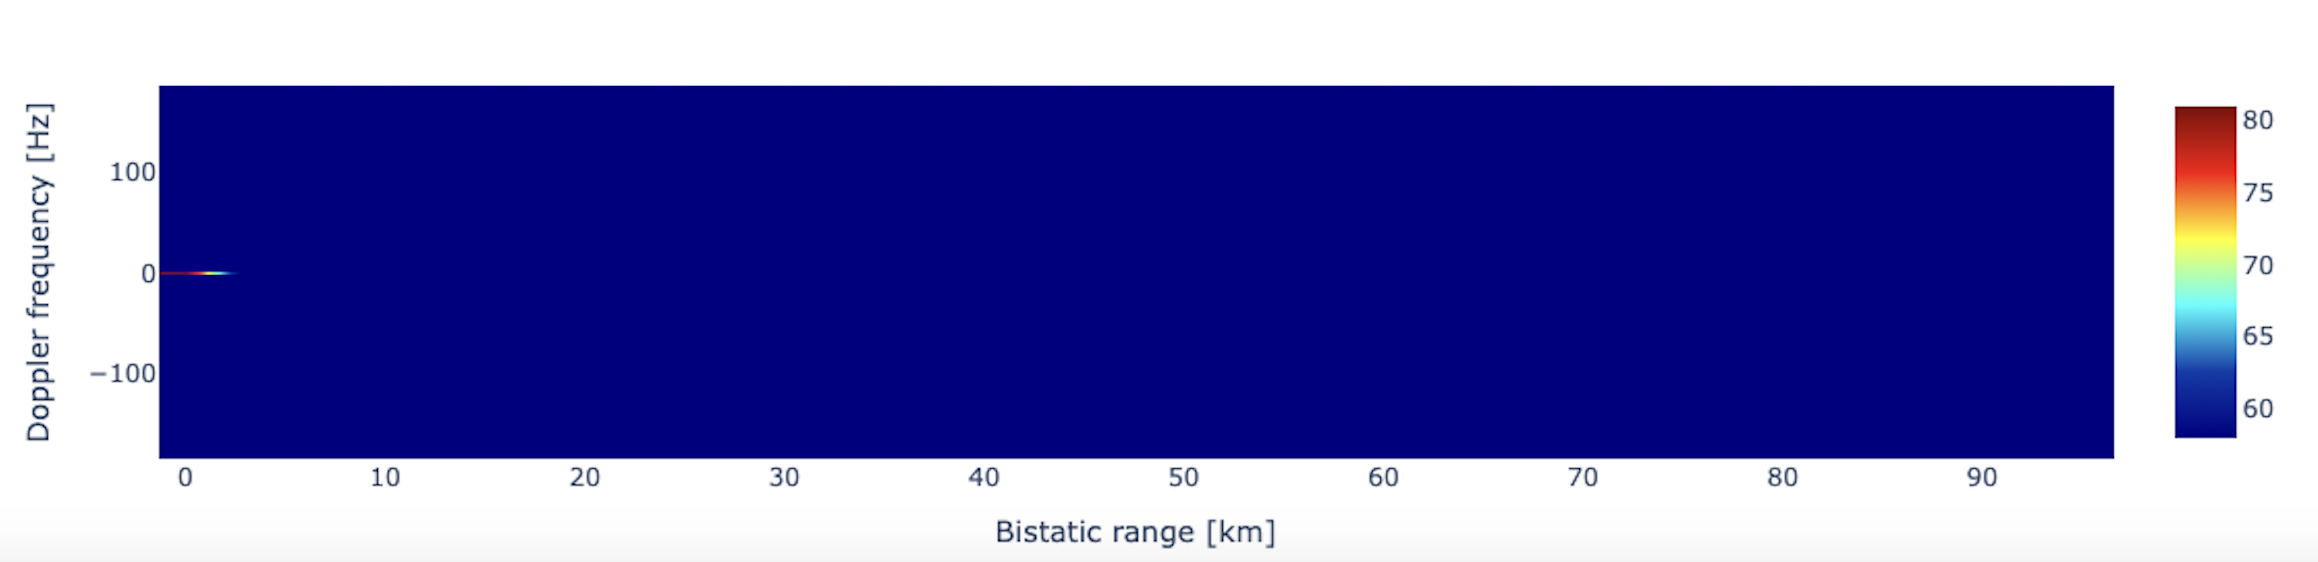

data/test/no_target/Ekran Resmi 2025-03-13 07.39.02.png 
data/test/no_target/Ekran Resmi 2025-03-13 07.39.02.png için tahmin sonucu: Hedef Yok ❌


In [45]:
# ✅ Hücre 10: Tahmin Örneği 4
image_path = "data/test/no_target/Ekran Resmi 2025-03-13 07.39.02.png"  # Örneği değiştir
print(f"{image_path} için tahmin sonucu: {predict(image_path, device=device)}")

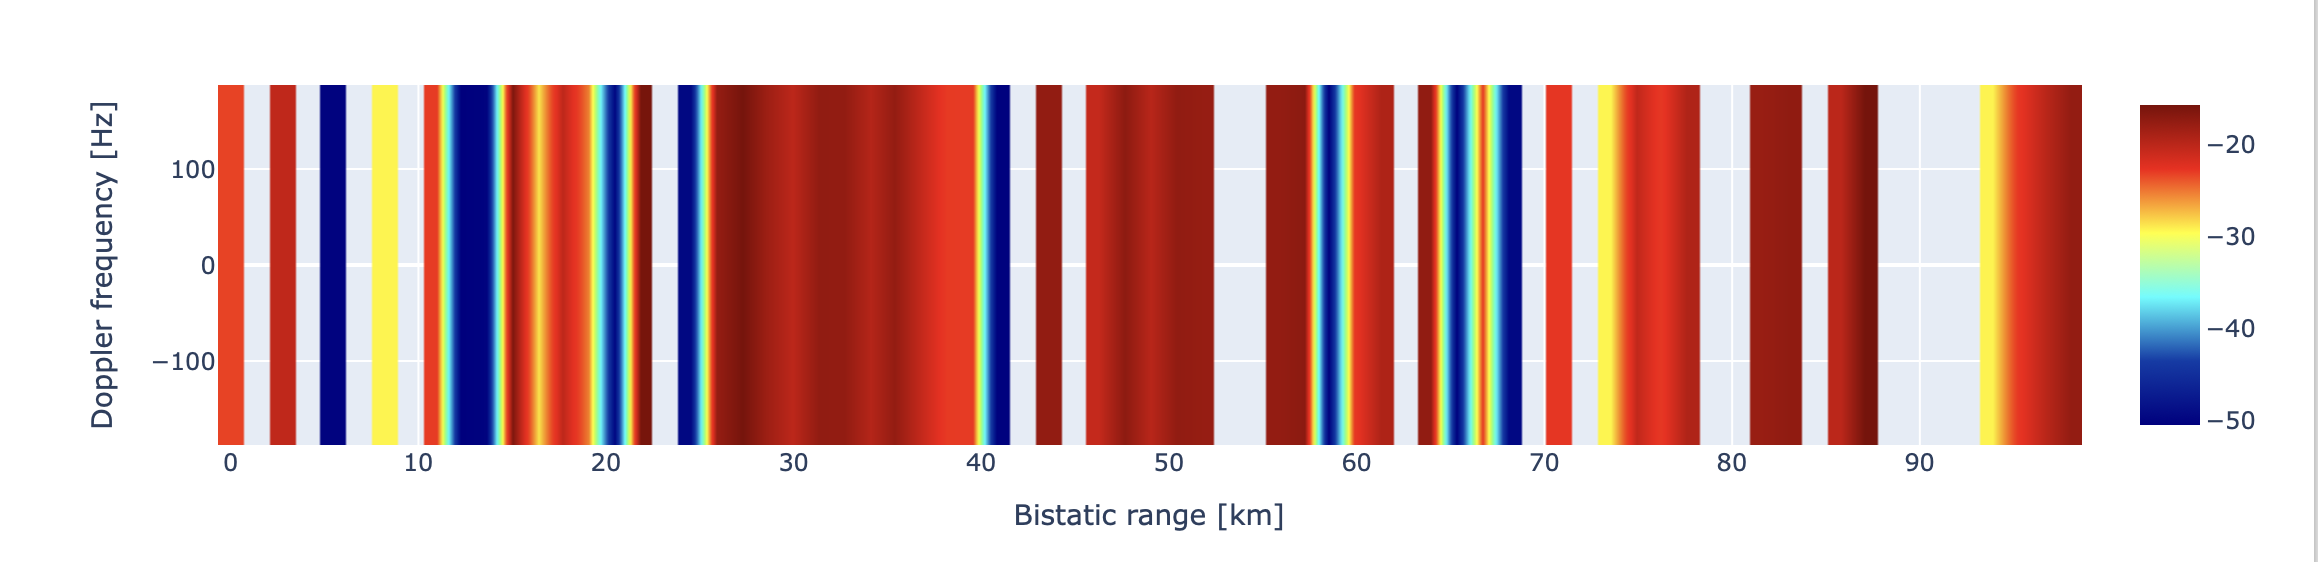

data/test/no_target/5-Erkin Koray - Aşka Dönüyorum 1969 (Plak Kaydı) (128kbit_AAC)Part003.png 
data/test/no_target/5-Erkin Koray - Aşka Dönüyorum 1969 (Plak Kaydı) (128kbit_AAC)Part003.png için tahmin sonucu: Hedef Yok ❌


In [46]:
# ✅ Hücre 11: Tahmin Örneği 5
image_path = "data/test/no_target/5-Erkin Koray - Aşka Dönüyorum 1969 (Plak Kaydı) (128kbit_AAC)Part003.png"  # Örneği değiştir
print(f"{image_path} için tahmin sonucu: {predict(image_path, device=device)}")

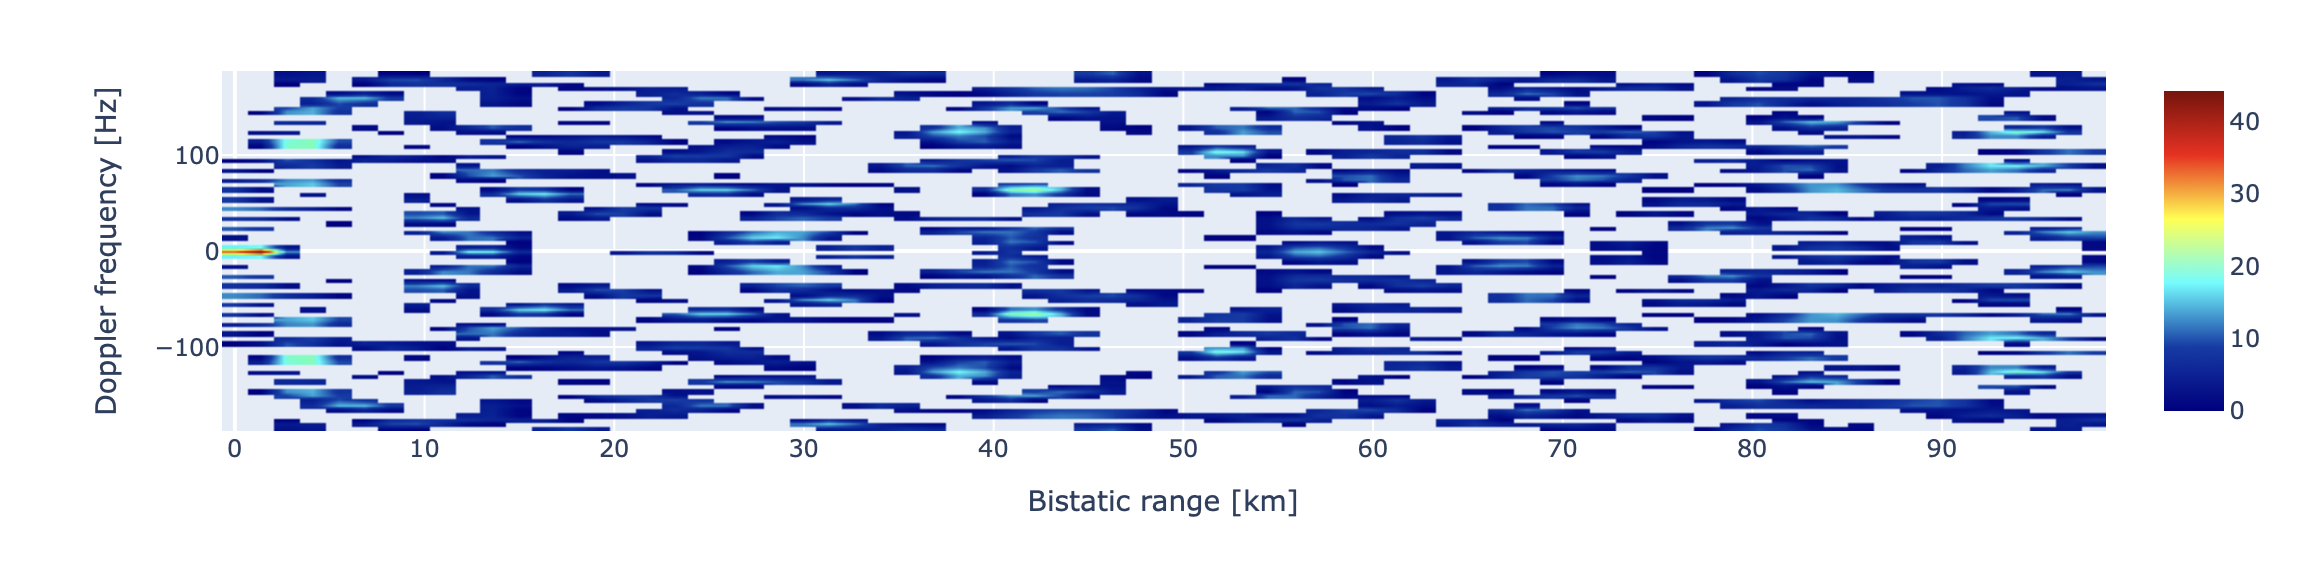

data/test/no_target/1-Enrico Macias   Zingarella  Gina Lollobrigida (128kbit_AAC)Part003.png 
data/test/no_target/1-Enrico Macias   Zingarella  Gina Lollobrigida (128kbit_AAC)Part003.png için tahmin sonucu: Hedef Yok ❌


In [47]:
# ✅ Hücre 12: Tahmin Örneği 6
image_path = "data/test/no_target/1-Enrico Macias   Zingarella  Gina Lollobrigida (128kbit_AAC)Part003.png"  # Örneği değiştir
print(f"{image_path} için tahmin sonucu: {predict(image_path, device=device)}")

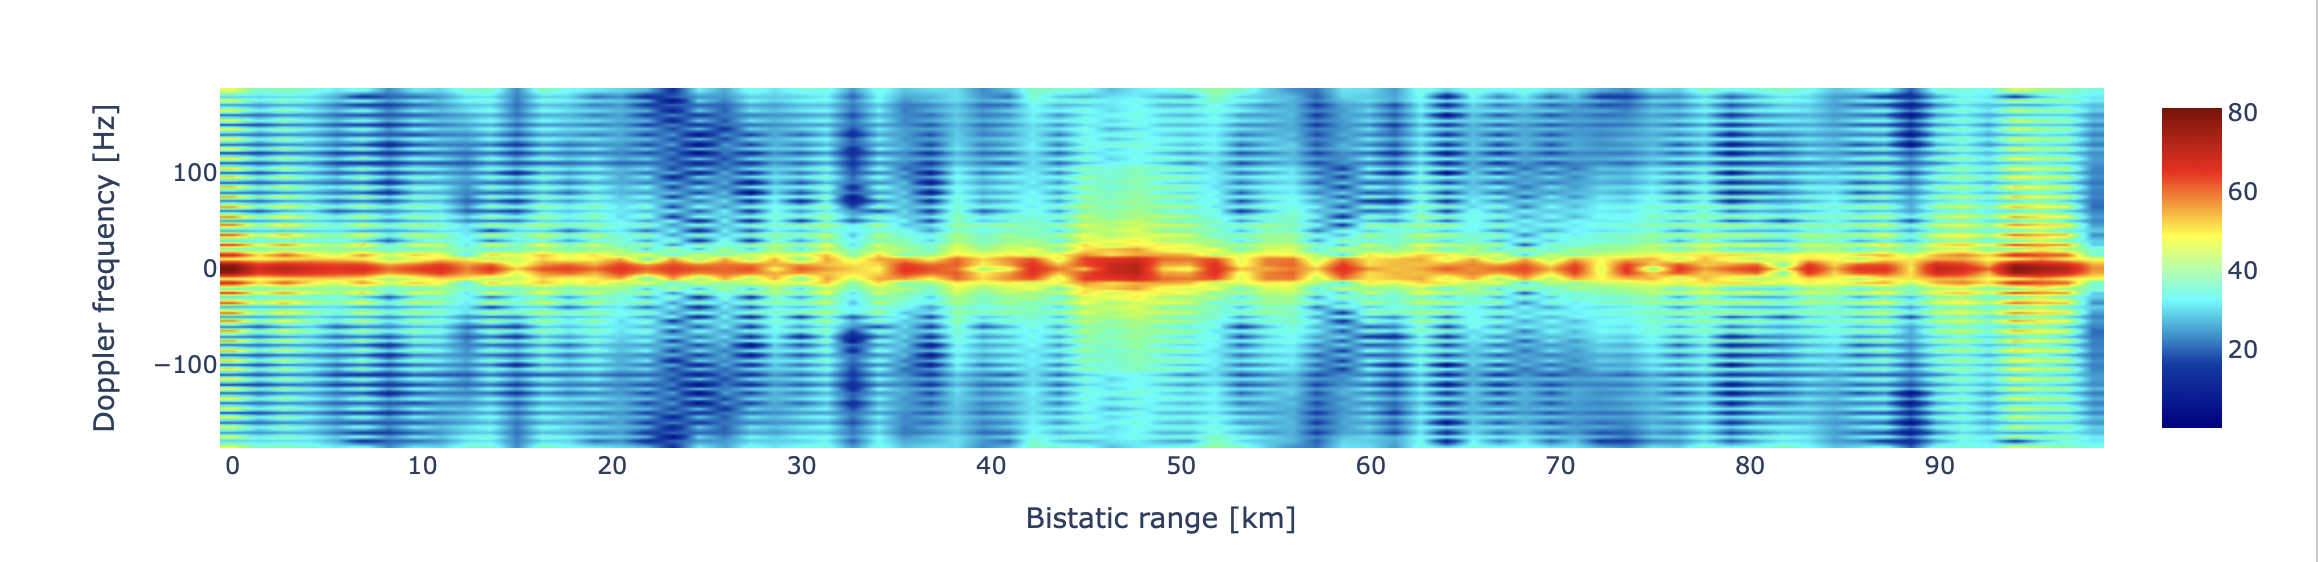

data/test/target/Ses Frekansı DİKKAT SİNİR BOZAR _D (128kbit_AAC)Part003.png 
data/test/target/Ses Frekansı DİKKAT SİNİR BOZAR _D (128kbit_AAC)Part003.png için tahmin sonucu: Hedef Var ✅


In [48]:
# ✅ Hücre 14: Tahmin Örneği 8
image_path = "data/test/target/Ses Frekansı DİKKAT SİNİR BOZAR _D (128kbit_AAC)Part003.png"  # Örneği değiştir
print(f"{image_path} için tahmin sonucu: {predict(image_path, device=device)}")

In [49]:
import os
import psutil

process = psutil.Process(os.getpid())
mem_info = process.memory_info().rss  # bayt cinsinden

print(f"Aktif Jupyter Notebook kernel RAM kullanımı: {mem_info / (1024 ** 2):.2f} MB")

Aktif Jupyter Notebook kernel RAM kullanımı: 427.09 MB
